# 01 トルク飽和

## 背景

00 では $\tau=0$ でプラントが動くことを見た。モータには上限がある。上限を無視した指令を `mjData.ctrl` に入れると、実機では出せない力をシミュレータが使ってしまう。

### 成功条件（数値。ここが合否）

姿勢崩壊は失敗ではない。飽和が 5 秒以上保たれること。[README §3.8](../docs/block-curriculum/00_README.md)。

| 量 | 条件 | 全ステップで連続 |
|---|---|---|
| クリップ | $\mathrm{clip}(200,\,\tau_{\min},\,\tau_{\max})=\tau_{\max}$（12 関節） | 定義どおり 1 回 print でも確認 |
| 適用トルク | 毎ステップ `mjData.ctrl` が `actuator_ctrlrange[:,1]` に一致 | 連続 $5.0\,\mathrm{s}$ 以上 |
| `qpos` | すべて有限 | 連続 $5.0\,\mathrm{s}$ 以上 |
| 結果 GIF | 1 本以上。実接触・合力・$mg$ | 必須 |

## 目的

- 生の $200\,\mathrm{N\cdot m}$ を `actuator_ctrlrange` で切る
- 切った $\tau$ で **5 秒以上** 走行し、GIF に実接触 GRF・合力・$mg$ を載せる
- 飽和が式どおりか、全ステップのログで確認する

## 数式

$$
\tau_{\mathrm{app}} = \mathrm{clip}(\tau_{\mathrm{raw}},\; \tau_{\min},\; \tau_{\max})
$$

## 図

```
tau_raw = 200
    |
    v
 clip to ctrlrange
    | tau_app
    v
  MuJoCo step  -->  GIF
```

## 思考過程

飽和は制御器ではなくアクチュエータの箱である。00 のあとに単独で見る。体重の分け方はまだ無い。

## 仮説

`raw=200` はすべての関節で上限を超える。5 秒間、適用値は上限のまま。姿勢は崩れてよい。


In [1]:
from pathlib import Path
import sys
import numpy as np
from IPython.display import Image, display

here = Path.cwd().resolve()
for p in [here, *here.parents]:
    if (p / "src" / "mpc_dog").is_dir():
        sys.path.insert(0, str(p / "src"))
        break

from mpc_dog.plant.mujoco_go2 import MujocoGo2
from mpc_dog.viz.gif import render_rollout_gif

HOLD_S = 5.0

def longest_true_seconds(flags, dt):
    best = cur = 0
    for f in flags:
        cur = cur + 1 if f else 0
        if cur > best:
            best = cur
    return best * float(dt)

def clip_torque(tau, ctrl_range):
    """出せないトルクを捨てる。この段の合否は静止ではなく、切った値が保たれること。"""
    u = np.asarray(tau, dtype=np.float64).reshape(-1)
    lo = np.asarray(ctrl_range[:, 0], dtype=np.float64)
    hi = np.asarray(ctrl_range[:, 1], dtype=np.float64)
    return np.clip(u, lo, hi)

plant = MujocoGo2(scene="flat", seed=0)
dt = plant.sim_dt
n_steps = int(np.ceil(HOLD_S / dt)) + int(round(0.5 / dt))
# 全関節 200 N·m は Go2 の上限（hip 23.7 / calf 45.4）を必ず超える。
raw = np.full(12, 200.0)
clipped = clip_torque(raw, plant.model.actuator_ctrlrange)
print("ctrlrange hi", plant.model.actuator_ctrlrange[:, 1])
print("clipped", clipped)
assert np.allclose(clipped, plant.model.actuator_ctrlrange[:, 1]), "200 Nm must saturate to hi"

ok_sat = []
ok_fin = []
for _ in range(n_steps):
    plant.step(clipped)
    ok_sat.append(bool(np.allclose(plant.data.ctrl, plant.model.actuator_ctrlrange[:, 1])))
    ok_fin.append(bool(np.isfinite(plant.data.qpos).all()))

hold_sat = longest_true_seconds(ok_sat, dt)
hold_fin = longest_true_seconds(ok_fin, dt)
print("t_end", float(plant.data.time), "hold_sat_s", hold_sat, "hold_finite_s", hold_fin)
assert hold_sat >= HOLD_S, f"saturation held {hold_sat:.3f}s < {HOLD_S}"
assert hold_fin >= HOLD_S
print("01 PASS: ctrl at hi for", hold_sat, "s")


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


ctrlrange hi [23.7  23.7  45.43 23.7  23.7  45.43 23.7  23.7  45.43 23.7  23.7  45.43]
clipped [23.7  23.7  45.43 23.7  23.7  45.43 23.7  23.7  45.43 23.7  23.7  45.43]


t_end 5.501999999999616 hold_sat_s 5.5 hold_finite_s 5.5
01 PASS: ctrl at hi for 5.5 s


/home/takuya/work/mpc_dog/notebook/assets/01_clip_torque.gif 2062578 bytes


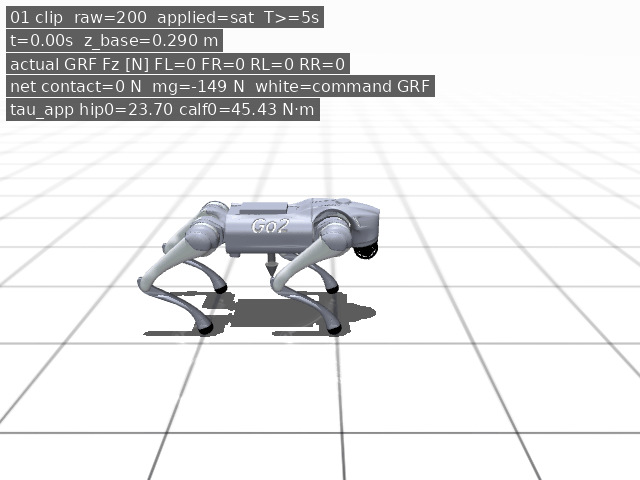

In [2]:
# 結果 GIF 必須。飽和後の tau で 5.5 s。姿勢崩壊はここでは失敗ではない。
plant = MujocoGo2(scene="flat", seed=0)
gif = Path("assets/01_clip_torque.gif")
path = render_rollout_gif(
    plant,
    gif,
    n_steps=n_steps,
    capture_every=60,
    tau=clipped,
    extra_lines=lambda p: [f"tau_app hip0={p.data.ctrl[0]:.2f} calf0={p.data.ctrl[2]:.2f} N·m"],
    title="01 clip  raw=200  applied=sat  T>=5s",
)
print(path.resolve(), path.stat().st_size, "bytes")
display(Image(filename=str(path)))


## 分析

結果 GIF は上のセル（必須。姿勢崩壊はここでは失敗ではない）。

- 生指令 200 N·m は範囲外。適用値は `clipped` とキャプションの `tau_app`
- 合否は「200 が上限に切れ、**連続 5.0 s** `ctrl` が上限のまま」こと。静止ではない

## 次の仮説

4 脚で $mg$ を等分し、仮想仕事 $-J^{\top}F$ で支える。00 の式では $h$ も残る。次で $J$ と $\tau$ を print する。
